In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

Shape of the training set is  (2000, 2) .
Shape of the test set is (1000, 2) .
Shape of the target vector is (2000, 1) .


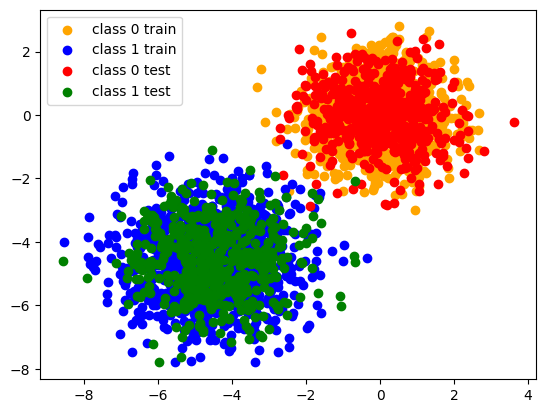

In [ ]:
np.random.seed(10)

# generate two classes of samples X_1 and X_2
X_1 =  np.random.randn(1500,2)
X_2 = 1.2*np.random.randn(1500,2)-4.5

# divide them into:
# training set
X_1_train = X_1[:1000, :]
X_2_train = X_2[:1000, :]

# test set
X_1_test = X_1[1000:, :]
X_2_test = X_2[1000:, :]



# X_train is training set used in algorithm
X_train = np.vstack([X_1_train, X_2_train])

# y is a set of tagrets
# The first 1000 samples are from class 0
y = np.zeros((2000,1))
# The last 1000 samples are from class 1
y[ 1000:, 0] = 1

X_test = np.vstack([X_1_test, X_2_test])
print('Shape of the training set is  (%i, %i) .'% X_train.shape)
print('Shape of the test set is (%i, %i) .'% X_test.shape)
print('Shape of the target vector is (%i, %i) .' % y.shape)


# plot training and test set
plt.scatter(X_1_train[:,0], X_1_train[:, 1], label = 'class 0 train', color = 'Orange')
plt.scatter(X_2_train[:,0], X_2_train[:, 1], label = 'class 1 train', color = 'Blue')

plt.scatter(X_1_test[:,0], X_1_test[:,1],label = 'class 0 test', color = 'r')
plt.scatter(X_2_test[:,0], X_2_test[:,1], label = 'class 1 test', color = 'g')

plt.legend()
plt.show()

In [ ]:
def loss_function(y,a):
    L = -(y * np.log(a) + (1-y)*np.log( 1-a))
    return L

In [ ]:
def derivative_calculations(X,y_target, w1, w2, b):

    # initialize values to 0
    dw1 = 0
    dw2 = 0
    db = 0
    J=0

    m = X.shape[0] # number od elements in the training set

    for i in range(m): # go through examples in the training set and calculate derivatives
        zi = w1 * X[i,0] + w2*X[i,1] + b
        ai = 1 / (1+ np.exp(-zi))
        J += loss_function(y_target[i,0], ai)

        dzi = ai - y_target[i,0]
        dw1 += X[i,0] * dzi  # here we do not need a for loop over n features, because we have just two features
        dw2 += X[i,1] * dzi
        db += dzi

    # calculate average values
    J/= m
    dw1/=m
    dw2/=m
    db/=m

    return dw1, dw2, db, J

In [ ]:
def iteration_step(X,y_target, num_it,alpha, w1, w2, b):

    # repeat calculation of derivatives to find global optimum
    w1_list = []
    w2_list = []
    b_list = []
    J_list = []
    for i in range(num_it):
        dw1, dw2, db, J_cost = derivative_calculations(X,y_target, w1, w2, b)

        # update parameters
        w1 = w1 - alpha * dw1
        w2 = w2 - alpha * dw2
        b = b - alpha * db

        # append value for each iteration
        w1_list.append(w1)
        w2_list.append(w2)
        b_list.append(b)
        J_list.append(J_cost)

    return w1_list, w2_list, b_list, J_list

In [ ]:
n_iterations = 100000
w1_list, w2_list, b_list, J_list = iteration_step(X_train,y, n_iterations,alpha=0.1, w1=0, w2=0, b=0)

In [ ]:
# in the following graphic we will see how parameters change
plt.plot(J_list,'b', label = 'J')
plt.plot(w1_list,'g', label ='$\omega1$')
plt.plot(w2_list,'r', label = '$\omega2$')
plt.xlabel('number of iteration')
plt.title('Evaluation of parameters')
plt.plot(b_list, label = 'b');
plt.legend()
plt.grid()
plt.show()

In [ ]:
# check the shape of parameters
# param_w_b is a dictionary which contains parameters w and b
# print shape of these parameters
print(param_w_b['w'].shape)
print(param_w_b['b'].shape)

In [ ]:
def make_predictions(w, b, X):

    m = X.shape[1]
    Y_predictions = np.zeros((1, m))


    A = sigmoid(np.dot(w.T, X) + b)

    for i in range(A.shape[1]):
        Y_predictions[0, i] = 1 if A[0, i] > 0.5 else 0


    assert(Y_predictions.shape == (1, m)) # assert is a way we care on matrix dimensions

    return Y_predictions

In [ ]:
# make predictions on both training set and test set
Y_predictions_train = make_predictions(param_w_b['w'], param_w_b['b'], X_train)
Y_predictions_test = make_predictions(param_w_b['w'], param_w_b['b'], X_test)

In [ ]:
# make some plots to see how algorithm works on training set, so on examples that had been seen

plt.subplot(1,2,1)
plt.scatter(X0_train[0,:],X0_train[1,:], color = 'Blue', label = 'class 0 test')
plt.scatter(X1_train[0,:],X1_train[1,:], color = 'Red', label = 'class 1 test')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.title('Test set')
plt.axis('equal')

plt.subplot(1,2,2)
plt.scatter(X0_train[0,:],X0_train[1,:], color = 'Blue', label = 'class 0 test')
plt.scatter(X1_train[0,:],X1_train[1,:], color = 'Red', label = 'class 1 test')
for i in range(0,1000):
    if Y_predictions_train[0,i] == 1 :
        plt.scatter(X_train[0,i],X_train[1,i], color = 'Red')
for i in range(1000,2000):
    if Y_predictions_train[0,i] == 0 :
        plt.scatter(X_train[0,i],X_train[1,i], color = 'Blue')

plt.xlabel('feature1')
plt.title('Classified')
plt.axis('equal')
plt.show()

# print the accuracy on the training set
print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_predictions_train - y_train)) * 100))


In [ ]:
# make some plots to see how algorithm works on unseen data

plt.subplot(1,2,1)
plt.scatter(X0_test[0,:],X0_test[1,:], color = 'LightBlue', label = 'class 0 test')
plt.scatter(X1_test[0,:],X1_test[1,:], color = 'Orange', label = 'class 1 test')
plt.ylabel('feature2')
plt.xlabel('feature1')
plt.title('Test set')
plt.axis('equal')

plt.subplot(1,2,2)
plt.scatter(X0_test[0,:],X0_test[1,:], color = 'LightBlue', label = 'class 0 test')
plt.scatter(X1_test[0,:],X1_test[1,:], color = 'Orange', label = 'class 1 test')
for i in range(0,500):
    if Y_predictions_test[0,i] == 1 :
        plt.scatter(X_test[0,i],X_test[1,i], color = 'Orange')
for i in range(500,1000):
    if Y_predictions_test[0,i] == 0 :
        plt.scatter(X_test[0,i],X_test[1,i], color = 'LightBlue')

plt.xlabel('feature1')
plt.axis('equal')
plt.title('Classified')
plt.show()

print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_predictions_test - y_test)) * 100))